In [2]:
import pandas as pd;
df=pd.read_csv("Tickets.csv")

In [3]:
df.head()

,Ticket ID,Source,Priority,Status,Category,Team,Agent Name,Creation Date and Time,Creation Date,Creation Time,First Response Date and Time,Resolution Date and Time,Closed Date and Time,Satisfactory Score,Target First Response Date and Time,Target Resolution Date and Time,First Response SLA,Resolution SLA
0,11001,On site,MEDIUM,Closed,Software,Bellis,Joe Butterick,1-1-2022 21:02:35,01-01-2022,21:02:35,2-1-2022 01:02:35,6-1-2022 05:02:35,6-1-2022 11:02:35,0.0,2-1-2022 03:02:35,7-1-2022 01:02:35,Achieved SLA,Achieved SLA
1,11002,On site,LOW,Closed,Others,Calla,Amory Bragg,1-1-2022 10:00:02,01-01-2022,10:00:02,1-1-2022 18:00:02,3-1-2022 09:00:02,3-1-2022 15:00:02,75.0,1-1-2022 18:00:02,9-1-2022 18:00:02,Achieved SLA,Achieved SLA
2,11003,Email,LOW,Closed,Hardware,Calla,Tarah Inwood,1-1-2022 18:29:23,01-01-2022,18:29:23,2-1-2022 01:29:23,10-1-2022 09:29:23,10-1-2022 15:29:23,100.0,2-1-2022 02:29:23,10-1-2022 01:29:23,Achieved SLA,Failed SLA
3,11004,Email,MEDIUM,Closed,Others,Bellis,Myrle Bonwell,1-1-2022 18:20:09,01-01-2022,18:20:09,1-1-2022 19:20:09,4-1-2022 03:20:09,4-1-2022 09:20:09,75.0,2-1-2022 00:20:09,6-1-2022 19:20:09,Achieved SLA,Achieved SLA
4,11005,On site,HIGH,Closed,Network,Furze,Doretta Bengefield,1-1-2022 12:26:27,01-01-2022,12:26:27,1-1-2022 15:26:27,2-1-2022 03:26:27,2-1-2022 09:26:27,25.0,1-1-2022 15:26:27,2-1-2022 15:26:27,Achieved SLA,Achieved SLA


In [4]:
df.columns

Index(['Ticket ID', 'Source', 'Priority', 'Status', 'Category', 'Team',
       'Agent Name', 'Creation Date and Time', 'Creation Date',
       'Creation Time', 'First Response Date and Time',
       'Resolution Date and Time', 'Closed Date and Time',
       'Satisfactory Score', 'Target First Response Date and Time',
       'Target Resolution Date and Time', 'First Response SLA',
       'Resolution SLA'],
      dtype='object')

In [5]:
df['Creation Date and Time'] = pd.to_datetime(
    df['Creation Date and Time'],
    dayfirst=True
)

df['Resolution Date and Time'] = pd.to_datetime(
    df['Resolution Date and Time'],
    dayfirst=True
)

In [6]:
df['Resolution Time Days'] = (
    df['Resolution Date and Time']
    - df['Creation Date and Time']
).dt.days

In [7]:
print(df['Resolution Time Days'].mean())

1.9380240842317635


In [8]:
print(df['Resolution Time Days'].max())

8.0


In [9]:
team_analysis = (
    df.groupby('Team')['Resolution Time Days']
      .mean()
      .sort_values(ascending=False)
)

print(team_analysis)

Team
Daisy     1.978554
Hoya      1.974950
Aster     1.973168
Bellis    1.963486
Calla     1.945860
Erica     1.942482
Gorse     1.877612
Furze     1.848896
Name: Resolution Time Days, dtype: float64


In [10]:
category_analysis = (
    df.groupby('Category')['Resolution Time Days']
      .mean()
      .sort_values(ascending=False)
)

print(category_analysis)

Category
Network     1.965311
Hardware    1.942431
Others      1.929341
Software    1.914904
Name: Resolution Time Days, dtype: float64


In [11]:
df.groupby('Category')['Satisfactory Score'].mean()

Category
Hardware    71.710356
Network     71.931476
Others      72.235547
Software    71.483781
Name: Satisfactory Score, dtype: float64

In [12]:
df['Resolution SLA'].value_counts()

Resolution SLA
Achieved SLA    14503
Failed SLA       1358
Name: count, dtype: int64

<Axes: xlabel='Category'>

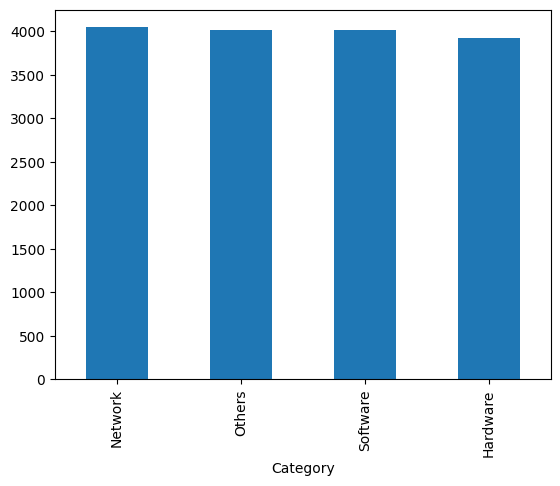

In [13]:
df['Category'].value_counts().plot(kind='bar')

<Axes: xlabel='Team'>

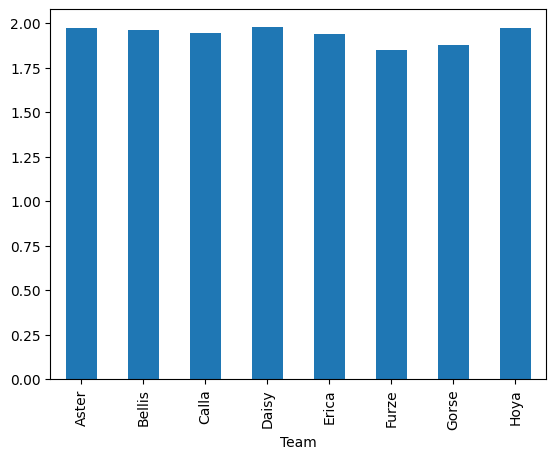

In [14]:
df.groupby('Team')['Resolution Time Days'].mean().plot(kind='bar')

<Axes: xlabel='Category'>

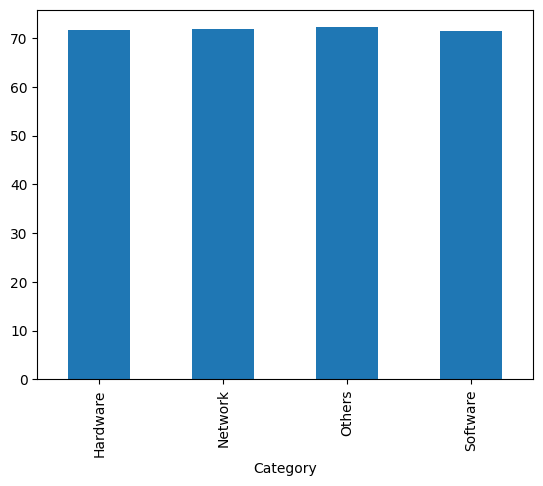

In [15]:
df.groupby('Category')['Satisfactory Score'].mean().plot(kind='bar')

In [16]:
df.columns

Index(['Ticket ID', 'Source', 'Priority', 'Status', 'Category', 'Team',
       'Agent Name', 'Creation Date and Time', 'Creation Date',
       'Creation Time', 'First Response Date and Time',
       'Resolution Date and Time', 'Closed Date and Time',
       'Satisfactory Score', 'Target First Response Date and Time',
       'Target Resolution Date and Time', 'First Response SLA',
       'Resolution SLA', 'Resolution Time Days'],
      dtype='object')

In [17]:
df.to_csv("tickets_cleaned.csv", index=False)